In [4]:
import numpy as np
import math
import cmath
from math import pi
import matplotlib.pyplot as plt, numpy as np, scipy.constants as ct

# Joshua Tensuan - ECE 3030 - HW 9

## Question 1

In [5]:
# declare variables
lambdas = np.linspace(0.3e-6, 0.9e-6, 5000) # wavelengths to scan over

# physical constants
mu_0 = 4 * math.pi * 1e-7
epsilon_0 = 8.85e-12

# impedances
eta_1 = (mu_0/epsilon_0) ** (1/2)
eta_2 = eta_1/(3.5 ** (1/2))
eta_3 = eta_1/3.5

# reflection
gamma_2 = (eta_3-eta_2)/(eta_3 + eta_2)

# constant
C = -4 * math.pi * (3.5 ** (1/2)) * (0.52e-6 / (4 * (3.5 ** (1/2))))

In [6]:
# store reflection coefficients squared
gamma_sq = []

# compute reflection coefficients
for curr_lambda in lambdas:
    complex_exp = complex(0, C/curr_lambda)
    gamma_L = gamma_2 * cmath.exp(complex_exp)
    curr_eta = eta_2 * ((1 + gamma_L)/(1 - gamma_L))
    curr_gamma = (curr_eta - eta_1) / (curr_eta + eta_1)
    gamma_sq.append(abs(curr_gamma) ** 2)

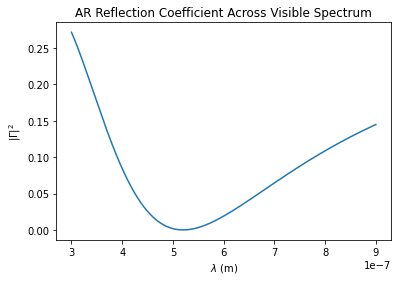

In [7]:
plt.figure(figsize = (6,4))
plt.plot(lambdas, gamma_sq)

plt.ylabel(r"$|\Gamma|^2$")
plt.xlabel(r"$\lambda$ (m)")
plt.title("AR Reflection Coefficient Across Visible Spectrum")
plt.show()

## Question 2

In [8]:
def transform_impedance(eta_l, eta_o, n_o, L, curr_lambda):
    # input: load impedance, layer impedance, layer index, and layer L
    # output: transformed impedance at start of layer
    gamma_curr = (eta_l-eta_o)/(eta_l+eta_o)
    C = -4 * math.pi * n_o * L
    complex_exp = complex(0, C/curr_lambda)
    gamma_L = gamma_curr * cmath.exp(complex_exp)
    trans_eta = eta_o * ((1+gamma_L) / (1-gamma_L))
    return trans_eta

In [9]:
# declare array of number pairs
arr_n_pairs = [1, 2, 4, 8, 16, 32]

# indices
n_2 = 2.4
n_3 = 1.5
n_4 = 3.5

# impedances
eta_1 = (mu_0/epsilon_0) ** (1/2)
eta_2 = eta_1/n_2
eta_3 = eta_1/n_3
eta_4 = eta_1/n_4

# layer lengths
l_2 = 0.52e-6 / (4 * n_2)
l_3 = 0.52e-6 / (4 * n_3)

# store gammas
arr_gammas_sq = np.zeros((len(arr_n_pairs), len(lambdas)))

In [10]:
# iterate over different N
for c1, n_pair in enumerate(arr_n_pairs):
    # iterate over different wavelengths
    for c2, curr_lambda in enumerate(lambdas):
        # starting impedance
        curr_eta = eta_4

        # go layer by layer
        for i in range(n_pair):
            # transform first layer
            curr_eta = transform_impedance(curr_eta, eta_3, n_3, l_3, curr_lambda)
            
            # transform second layer
            curr_eta = transform_impedance(curr_eta, eta_2, n_2, l_2, curr_lambda)
        curr_gamma = (curr_eta - eta_1) / (curr_eta + eta_1)
        arr_gammas_sq[c1][c2] = abs(curr_gamma) ** 2

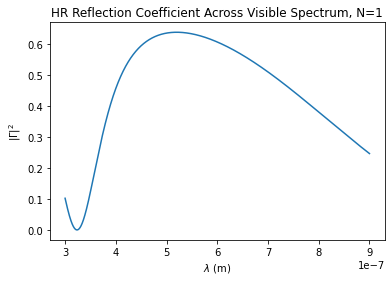

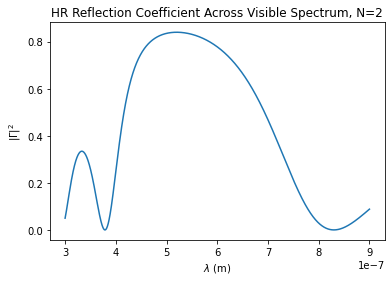

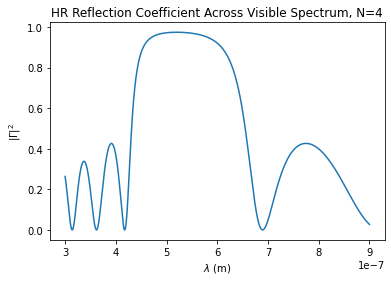

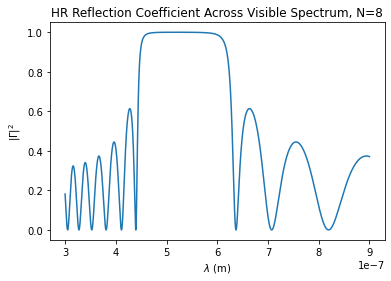

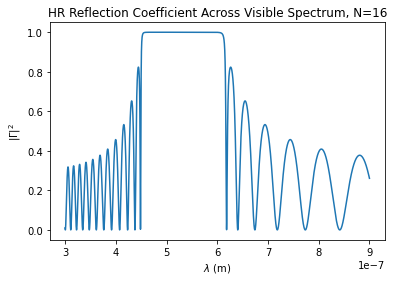

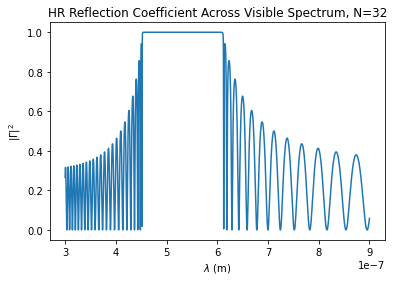

In [11]:
# plots of gamma for HR
plt.figure(figsize = (6,4))
plt.plot(lambdas, arr_gammas_sq[0])
plt.ylabel(r"$|\Gamma|^2$")
plt.xlabel(r"$\lambda$ (m)")
plt.title("HR Reflection Coefficient Across Visible Spectrum, N=1")
plt.show()

plt.figure(figsize = (6,4))
plt.plot(lambdas, arr_gammas_sq[1])
plt.ylabel(r"$|\Gamma|^2$")
plt.xlabel(r"$\lambda$ (m)")
plt.title("HR Reflection Coefficient Across Visible Spectrum, N=2")
plt.show()

plt.figure(figsize = (6,4))
plt.plot(lambdas, arr_gammas_sq[2])
plt.ylabel(r"$|\Gamma|^2$")
plt.xlabel(r"$\lambda$ (m)")
plt.title("HR Reflection Coefficient Across Visible Spectrum, N=4")
plt.show()

plt.figure(figsize = (6,4))
plt.plot(lambdas, arr_gammas_sq[3])
plt.ylabel(r"$|\Gamma|^2$")
plt.xlabel(r"$\lambda$ (m)")
plt.title("HR Reflection Coefficient Across Visible Spectrum, N=8")
plt.show()

plt.figure(figsize = (6,4))
plt.plot(lambdas, arr_gammas_sq[4])
plt.ylabel(r"$|\Gamma|^2$")
plt.xlabel(r"$\lambda$ (m)")
plt.title("HR Reflection Coefficient Across Visible Spectrum, N=16")
plt.show()

plt.figure(figsize = (6,4))
plt.plot(lambdas, arr_gammas_sq[5])
plt.ylabel(r"$|\Gamma|^2$")
plt.xlabel(r"$\lambda$ (m)")
plt.title("HR Reflection Coefficient Across Visible Spectrum, N=32")
plt.show()

# Question 3

In [28]:
len_omegas = 5000
# all frequencies to plot
plot_omegas = np.linspace(1.414e11, 1e12, len_omegas)
arr_v_p = np.zeros(len_omegas)
arr_v_g = np.zeros(len_omegas)

c1 = 4 * mu_0 * epsilon_0
c2 = ((3/0.01) * math.pi ) ** 2

# compute phase and group velocities
for counter, curr_omega in enumerate(plot_omegas):
    arr_v_p[counter] = curr_omega / ((c1 * (curr_omega ** 2) - c2) ** (1/2))
    arr_v_g[counter] = ((c1 * (curr_omega ** 2) - c2) ** (1/2)) / (c1 * curr_omega)


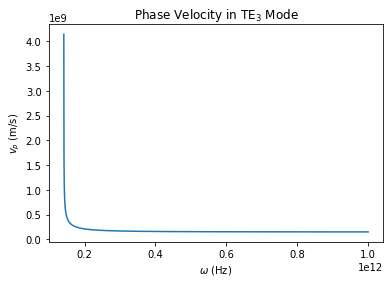

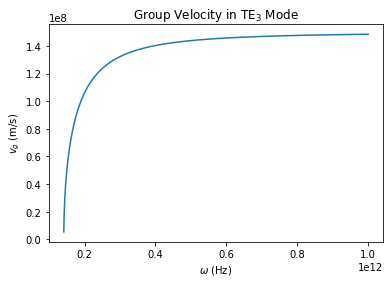

In [29]:
# plot phase velocity
plt.figure(figsize = (6,4))
plt.plot(plot_omegas, arr_v_p)
plt.ylabel(r"$v_p$ (m/s)")
plt.xlabel(r"$\omega$ (Hz)")
plt.title(r"Phase Velocity in $\mathrm{TE}_3$ Mode")
plt.show()

# plot group velocity
plt.figure(figsize = (6,4))
plt.plot(plot_omegas, arr_v_g)
plt.ylabel(r"$v_g$ (m/s)")
plt.xlabel(r"$\omega$ (Hz)")
plt.title(r"Group Velocity in $\mathrm{TE}_3$ Mode")
plt.show()